# Figures

- This script will create the figures for the decline in Antarctic Bottom Water

## Figure 1 preload:

In [1]:
import xarray as xr 

In [23]:
aabw_fraction_masked = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/aabw_fraction_masked.nc').aabw_fraction_masked
etopo_masked = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/etopo_masked.nc').etopo_masked
gamma_n_04 = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/gamma_n_04.nc').gamma_n_04
sal_04 = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/sal_04.nc').sal_04
sal_g =  xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/sal_g.nc').sal_g
sal_in_zone =  xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/sal_in_zone.nc').sal_in_zone
selected_profiles =  xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/selected_profiles.nc').selected_profiles
temp_04 = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/temp_04.nc').temp_04
temp_g = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/temp_g.nc').temp_g
temp_in_zone = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/temp_in_zone.nc').temp_in_zone

In [22]:
selected_profiles

<xarray.Dataset> Size: 2MB
Dimensions:            (N_PROF: 201, pressure: 1200)
Coordinates:
  * N_PROF             (N_PROF) int64 2kB 321 470 488 489 ... 1137 1138 1156
  * pressure           (pressure) float64 10kB 2.5 7.5 ... 5.992e+03 5.998e+03
    latitude           (N_PROF) float64 2kB ...
    longitude          (N_PROF) float64 2kB ...
    float_id           (N_PROF) float64 2kB ...
    gamma_n            float64 8B ...
Data variables:
    selected_profiles  (N_PROF, pressure) float64 2MB ...

In [14]:
ssh_thermosteric = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/ssh_thermosteric.nc').__xarray_dataarray_variable__
ssh_circumpolar_mean = ssh_thermosteric.mean(dim='time',skipna=False)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'labels'
  result = super().contour(*args, **kwargs)


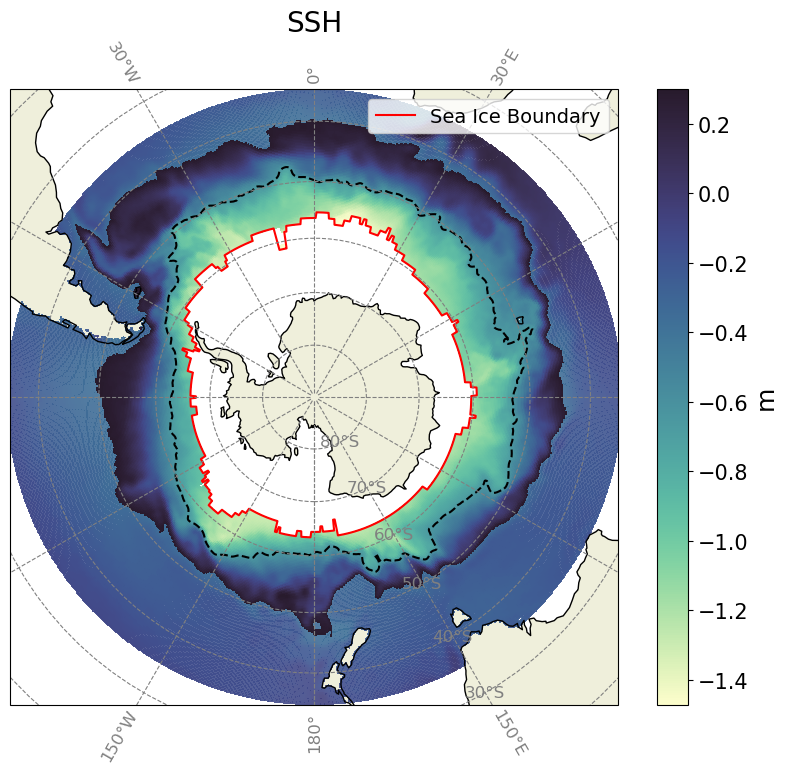

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean


# Select the data for longitude = 0.125
data_at_0_125 = ssh_circumpolar_mean.sel(longitude=0.125)

# Assign this data to a new longitude = 360.125
data_at_360_125 = data_at_0_125.assign_coords(longitude=360.125)

# Concatenate the new longitude data with the existing dataset
ssh_with_360_125 = xr.concat([ssh_circumpolar_mean, data_at_360_125], dim='longitude')

# Sort the longitudes to maintain the correct order
ssh_with_360_125 = ssh_with_360_125.sortby('longitude')


# Assume mean_ssh_with_nans is a 2D array (lat x lon) with coordinates latitude and longitude
longitude = ssh_with_360_125.longitude.values
latitude = ssh_with_360_125.latitude.values
data = ssh_with_360_125

sie_mask = np.full(longitude.shape, np.nan)

# Create a copy of your original data to mask
data_masked = xr.full_like(data, np.nan)

gap_threshold = 10  # number of grid cells considered a gap

for i, lon in enumerate(longitude):
    column = data[:, i].values  # SSH column at this longitude
    valid = ~np.isnan(column)
    
    if not np.any(valid):
        continue

    # Find the first valid SSH value <= 0.3 (southernmost)
    below_thresh = column <= 0.3
    below_thresh_indices = np.where(below_thresh & valid)[0]
    
    if len(below_thresh_indices) == 0:
        continue

    southernmost_index = below_thresh_indices[0]
    sie_mask[i] = latitude[southernmost_index]

    # Search northward for any gap of `gap_threshold` where SSH > 0.3
    north_of_edge = column[southernmost_index + 1:]
    above_thresh = north_of_edge > 0.3

    # Run-length encode to find gaps of 5 or more
    gap_length = 0
    for j, val in enumerate(above_thresh):
        if val:
            gap_length += 1
        else:
            if gap_length >= gap_threshold:
                # Mask everything from this point onward
                cutoff_index = southernmost_index + 1 + j
                column[cutoff_index:] = np.nan
                break
            gap_length = 0

    # Apply threshold mask (retain only values <= 0.3)
    column[column > 0.3] = np.nan

    # Save masked column back into masked data
    data_masked[:, i] = column


mask = ssh_with_360_125 <= 0.45

# Use xarray's where function to assign values only where the mask is true
data_masked = data_masked.where(~mask, 
    data)

# Plotting
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Add features such as coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND)

# Set the extent (latitude in southern hemisphere and longitude)
ax.set_extent([-180, 180, -80, -35], crs=ccrs.PlateCarree())

# Plot the temperature data
temp = ax.pcolormesh(
    longitude, latitude, ssh_circumpolar_mean, 
    shading='nearest', cmap=cmocean.cm.deep, 
    transform=ccrs.PlateCarree(), alpha = 0.9
)

temp = ax.pcolormesh(
    longitude, latitude, data_masked, 
    shading='nearest', cmap=cmocean.cm.deep, 
    transform=ccrs.PlateCarree()
)

# Add the southern boundary contour
ax.plot(longitude, sie_mask, 'r-', transform=ccrs.PlateCarree(), label='Sea Ice Boundary')

plt.contour(    ssh_circumpolar_mean.longitude, 
    ssh_circumpolar_mean.latitude, 
    ssh_circumpolar_mean, levels =[-0.65], colors='k', labels='PF',transform=ccrs.PlateCarree())


# Add a colorbar with the appropriate label
cbar = plt.colorbar(temp, ax=ax, orientation='vertical', label='m')

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, xlocs=range(-180, 181, 30), linestyle='--', color='gray')
gl.top_labels = True
gl.bottom_labels = True
gl.right_labels = True
gl.left_labels = True
gl.xlabel_style = {'size': 12, 'color': 'gray'}
gl.ylabel_style = {'size': 12, 'color': 'gray'}

# Add a title and legend
plt.title('SSH')
plt.legend(loc='upper right')

# Display the map
plt.show()


In [51]:
area_mask = data_masked.isnull()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14
})

import cartopy.mpl.gridliner as cgrid

import matplotlib.ticker as mticker

def add_grid(ax):
    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.8,
        color="white",
        alpha=0.8,
        linestyle="--"
    )
    # Turn on labels all around if you want
    gl.top_labels = True
    gl.right_labels = True
    gl.bottom_labels = True
    gl.left_labels = True

    # Set tick label style
    gl.xlabel_style = {"color": "black", "size": 14}
    gl.ylabel_style = {"color": "black", "size": 14}

    # Force all longitudes to be labelled
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))  # every 30°
    gl.ylocator = mticker.FixedLocator(np.arange(-80, -39, 10))   # every 10° for latitude

    return gl

proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

g = 28.28

## Figure 1

In [30]:
etopo_masked

<xarray.DataArray 'etopo_masked' (latitude: 180, longitude: 1440)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * latitude   (latitude) float32 720B -79.88 -79.62 -79.38 ... -35.38 -35.12
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
    y          (latitude) float64 1kB ...
    x          (longitude) float64 12kB ...
    time       datetime64[ns] 8B ...
Attributes:
    long_name:     z
    actual_range:  [-10803.   8333.]

In [34]:
etopo_sr3 = etopo_masked.sel(longitude=temp_04.longitude.sel(longitude=143.125),latitude=temp_04.latitude,method='nearest')

levels = np.arange(0, 50 + 1, 5)
norm = mcolors.BoundaryNorm(levels, ncolors=256, extend='both')


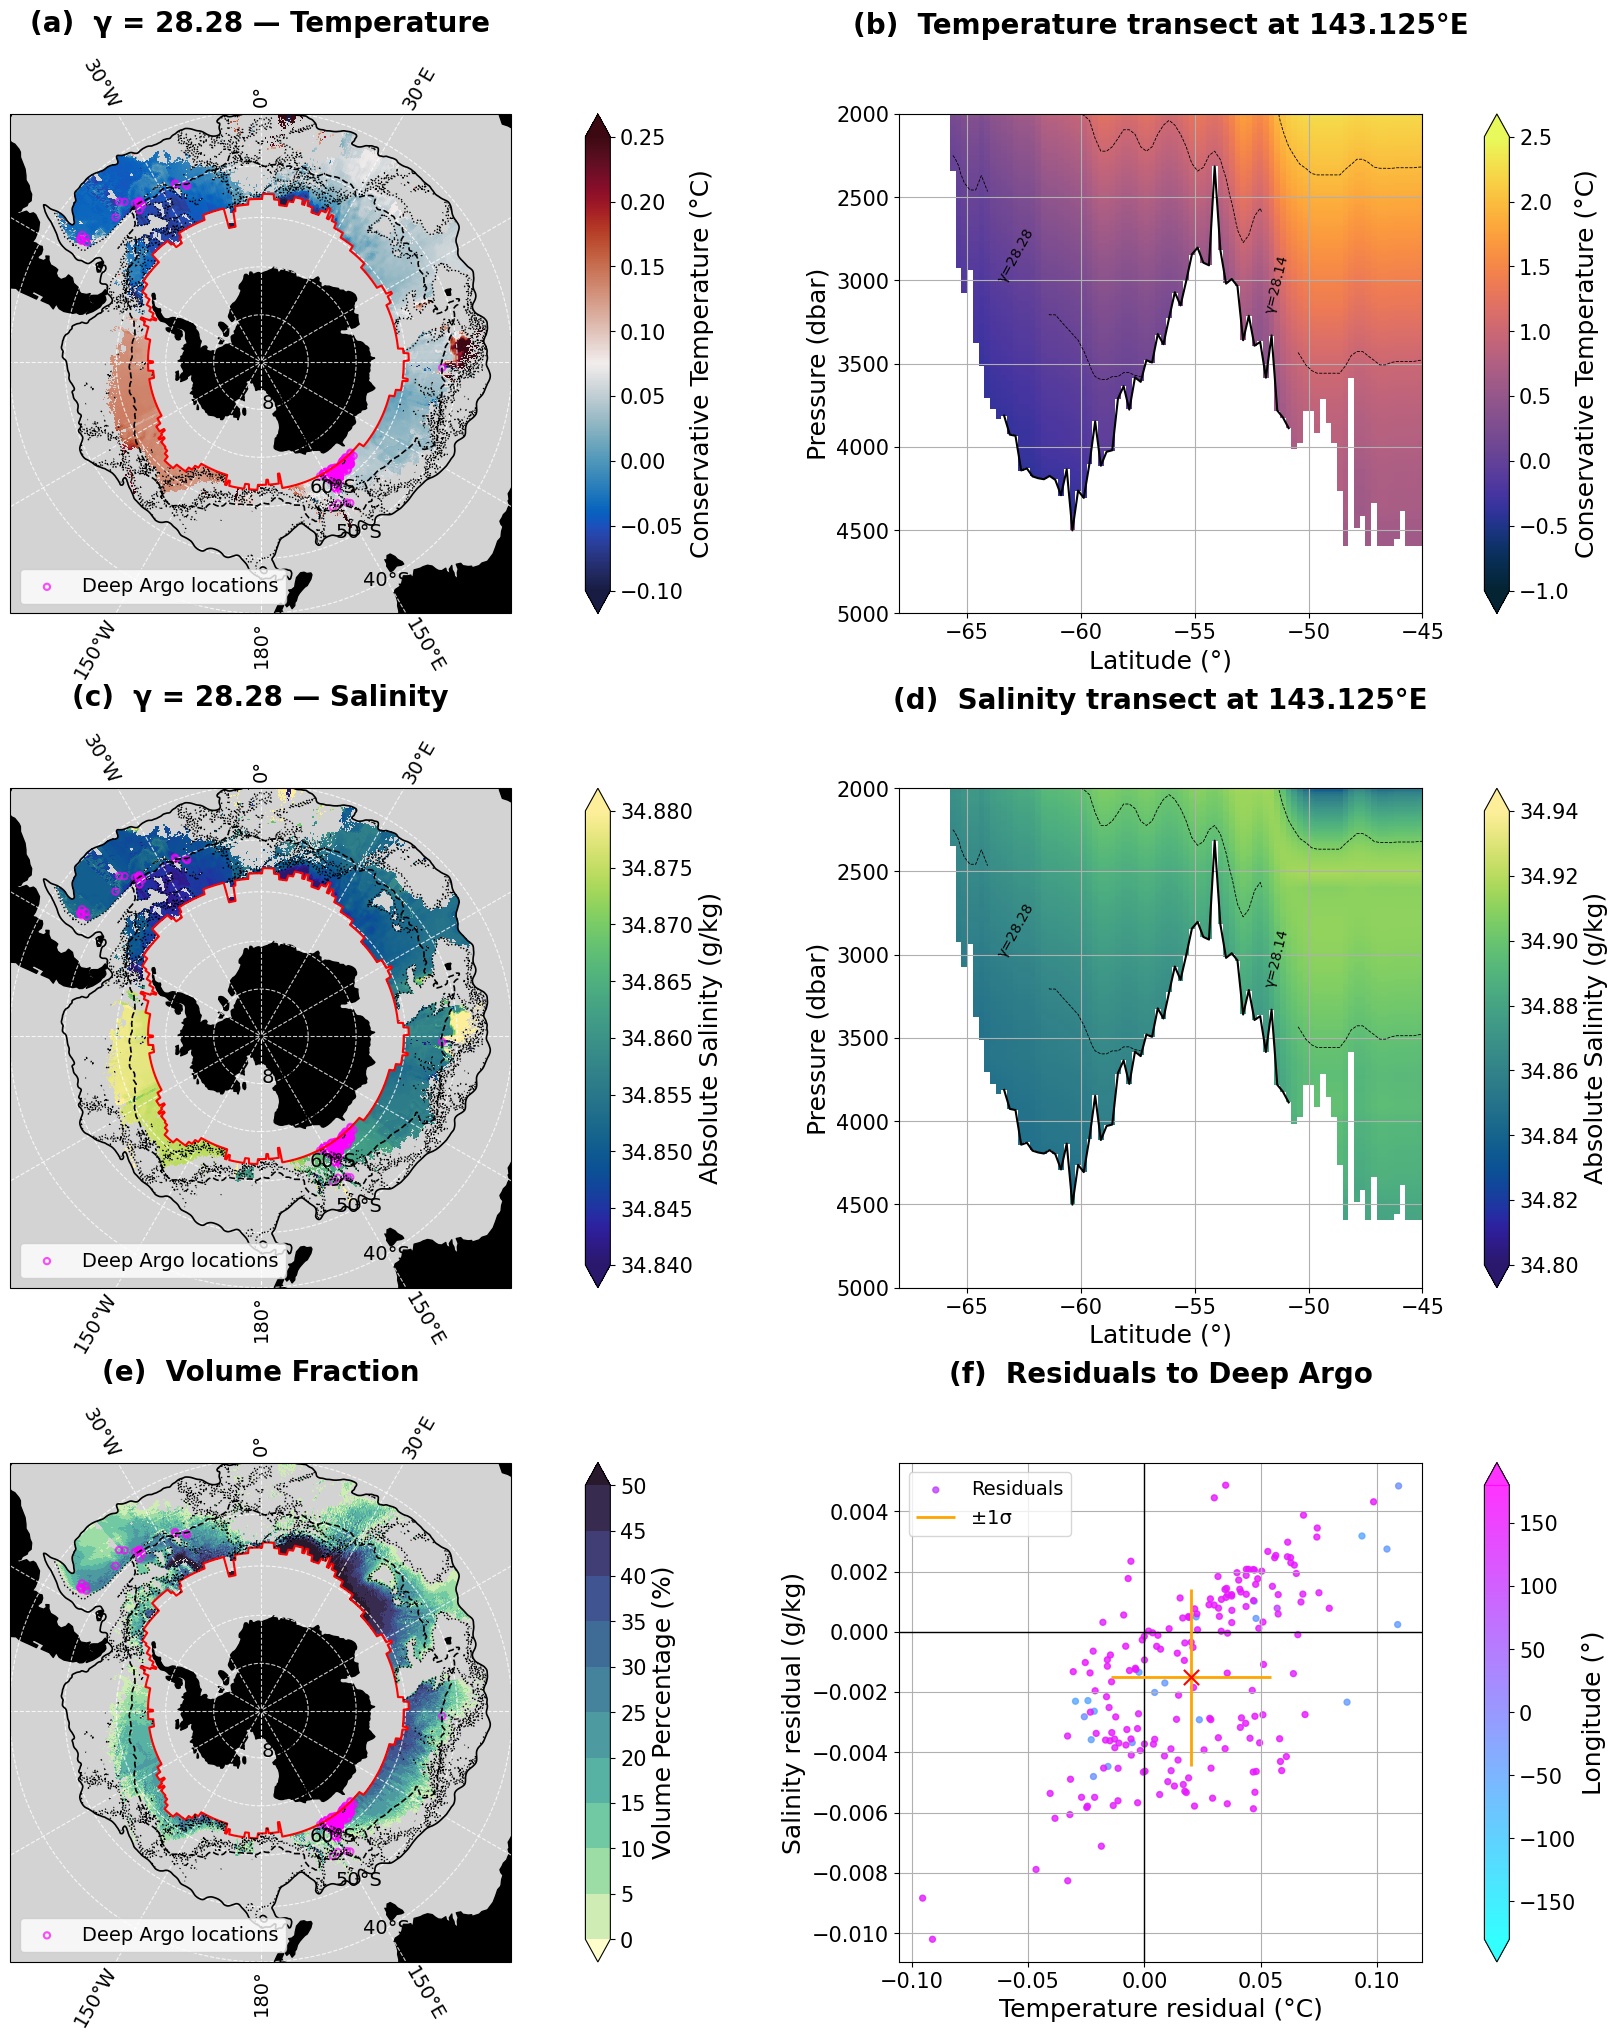

In [35]:
# =========================
# 3 x 2 layout
# Left: maps (T, S, Volume)
# Right: 1D/section plots (temp_04, sal_04, residuals)
# =========================


wm_bounds  = [28.0, 28.14, 28.28] 

fig = plt.figure(figsize=(22, 24), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[1.2, 1.0],
    height_ratios=[1, 1, 1],
    wspace=0.25, hspace=0.35
)

letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

# --------------------------------------------------
# ROW 1, COL 1: Temperature map
# --------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0], projection=proj)

ax0.coastlines()
ax0.set_facecolor("lightgray")  # ocean background
ax0.add_feature(cfeature.LAND, facecolor="black", zorder=2)
ax0.set_extent([-180, 180, -80, -40], crs=data_crs)

imT = ax0.pcolormesh(
    temp_g.longitude, temp_g.latitude, temp_g,
    vmin=-0.1, vmax=0.25, transform=data_crs,
    cmap=cmocean.cm.balance, shading="nearest"
)
cbt = plt.colorbar(imT, ax=ax0, orientation='vertical', pad=0.09, extend='both' )
cbt.set_label('Conservative Temperature (°C)')
ax0.set_title(f"{letters[0]}  γ = {g:.2f} — Temperature", weight='bold', pad=18)

add_grid(ax0)
ax0.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude,
    ssh_circumpolar_mean, levels=[-0.65, 0.3], colors='k',
    linewidths=1.2, transform=data_crs
)
ax0.contour(
    etopo_masked.longitude, etopo_masked.latitude, etopo_masked,
    levels=[-3500], colors='k', linewidths=1.0, linestyles=':',
    transform=data_crs
)
ax0.scatter(
    selected_profiles.longitude,
    selected_profiles.latitude,
    s=20,
    alpha=0.7,
    transform=data_crs,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.5,
    label="Deep Argo locations"
)
ax0.plot(longitude, sie_mask, 'r-', transform=data_crs)
ax0.legend(loc="lower left")

# --------------------------------------------------
# ROW 1, COL 2: temp_04 at longitude = 143.125
# --------------------------------------------------
# --------------------------------------------------
# ROW 1, COL 2: Temperature transect at 143.125°E
# --------------------------------------------------
ax1 = fig.add_subplot(gs[0, 1])  # no projection

temp_sec = temp_04.sel(longitude=143.125, method="nearest")

imT_sec = ax1.pcolormesh(
    temp_04.latitude,
    temp_04.pressure,
    temp_sec.T,                     # (pressure, latitude)
    cmap=cmocean.cm.thermal,
    shading="nearest",
    vmin=-1, vmax=2.5            # to match the map; tweak if needed
)

cbT_sec = plt.colorbar(imT_sec, ax=ax1, orientation="vertical", pad=0.09, extend='both' )
cbT_sec.set_label("Conservative Temperature (°C)")

ax1.plot(etopo_sr3.latitude, -etopo_sr3, color='black')
CS_T = ax1.contour(
    gamma_n_04.latitude, gamma_n_04.pressure,
    gamma_n_04.sel(longitude=143.125, method="nearest").T,
    levels=wm_bounds,
    colors='black', linestyles='--', linewidths=0.6
)
ax1.clabel(
    CS_T,
    inline=True,
    fontsize=10,
    fmt=lambda x: f"γ={x:.2f}"
)

ax1.set_xlabel("Latitude (°)")
ax1.set_ylabel("Pressure (dbar)")
ax1.set_ylim(2000,5000)
ax1.invert_yaxis()                  # flip axis so surface at top
ax1.set_xlim(-68,-45)
ax1.set_title(
    f"{letters[1]}  Temperature transect at 143.125°E",
    weight="bold", pad=18, y = 1.11
)
ax1.grid(True)


# --------------------------------------------------
# ROW 2, COL 1: Salinity map
# --------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0], projection=proj)

ax2.coastlines()
ax2.set_facecolor("lightgray")  # ocean background
ax2.add_feature(cfeature.LAND, facecolor="black", zorder=2)
ax2.set_extent([-180, 180, -80, -40], crs=data_crs)

imS = ax2.pcolormesh(
    sal_g.longitude, sal_g.latitude, sal_g,
    vmin=34.84, vmax=34.88, transform=data_crs,
    cmap=cmocean.cm.haline, shading="nearest"
)
cbs = plt.colorbar(imS, ax=ax2, orientation='vertical', pad=0.09,extend='both' )
cbs.set_label('Absolute Salinity (g/kg)')
ax2.set_title(f"{letters[2]}  γ = {g:.2f} — Salinity", weight='bold', pad=18)

add_grid(ax2)
ax2.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude,
    ssh_circumpolar_mean, levels=[-0.65, 0.3], colors='k',
    linewidths=1.2, transform=data_crs
)
ax2.contour(
    etopo_masked.longitude, etopo_masked.latitude, etopo_masked,
    levels=[-3500], colors='k', linewidths=1.0, linestyles=':',
    transform=data_crs
)
ax2.scatter(
    selected_profiles.longitude,
    selected_profiles.latitude,
    s=20,
    alpha=0.7,
    transform=data_crs,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.5,
    label="Deep Argo locations"
)
ax2.plot(longitude, sie_mask, 'r-', transform=data_crs)
ax2.legend(loc="lower left")

# --------------------------------------------------
# ROW 2, COL 2: sal_04 at longitude = 143.125
# --------------------------------------------------

ax3 = fig.add_subplot(gs[1, 1])  # no projection

sal_sec = sal_04.sel(longitude=143.125, method="nearest")

imS_sec = ax3.pcolormesh(
    sal_04.latitude,
    sal_04.pressure,
    sal_sec.T,                      # (pressure, latitude)
    cmap=cmocean.cm.haline,         # or thermal too if you want both as thermal
    shading="nearest",
    vmin=34.8, vmax=34.94        # to match the map; tweak if needed
)

cbS_sec = plt.colorbar(imS_sec, ax=ax3, orientation="vertical", pad=0.09,extend='both' )
cbS_sec.set_label("Absolute Salinity (g/kg)")

ax3.plot(etopo_sr3.latitude, -etopo_sr3, color='black')
CS_S = ax3.contour(
    gamma_n_04.latitude, gamma_n_04.pressure,
    gamma_n_04.sel(longitude=143.125, method="nearest").T,
    levels=wm_bounds,
    colors='black', linestyles='--', linewidths=0.6
)
ax3.clabel(
    CS_S,
    inline=True,
    fontsize=10,
    fmt=lambda x: f"γ={x:.2f}"
)
ax3.set_xlabel("Latitude (°)")
ax3.set_ylabel("Pressure (dbar)")
ax3.set_ylim(2000,5000)
ax3.invert_yaxis()                  # flip axis
ax3.set_xlim(-68,-45)
ax3.set_title(
    f"{letters[3]}  Salinity transect at 143.125°E",
    weight="bold", pad=18,  y = 1.11
)
ax3.grid(True)
# --------------------------------------------------
# ROW 3, COL 1: Volume fraction map
# --------------------------------------------------
ax4 = fig.add_subplot(gs[2, 0], projection=proj)

ax4.coastlines()
ax4.set_facecolor("lightgray")  # ocean background
ax4.add_feature(cfeature.LAND, facecolor="black", zorder=2)
ax4.set_extent([-180, 180, -80, -40], crs=data_crs)

imV = ax4.pcolormesh(
    aabw_fraction_masked.longitude, aabw_fraction_masked.latitude,
    aabw_fraction_masked * 100.0,
    transform=data_crs, cmap=cmocean.cm.deep, norm=norm, shading="nearest"
)
cbv = plt.colorbar(imV, ax=ax4, orientation='vertical', pad=0.09, ticks=levels)
cbv.set_label('Volume Percentage (%)')
ax4.set_title(f"{letters[4]}  Volume Fraction", weight='bold', pad=18)

add_grid(ax4)
ax4.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude,
    ssh_circumpolar_mean, levels=[-0.65, 0.3], colors='k',
    linewidths=1.2, transform=data_crs
)
ax4.plot(longitude, sie_mask, 'r-', transform=data_crs)
ax4.contour(
    etopo_masked.longitude, etopo_masked.latitude, etopo_masked,
    levels=[-3500], colors='k', linewidths=1.0, linestyles=':',
    transform=data_crs
)
ax4.scatter(
    selected_profiles.longitude,
    selected_profiles.latitude,
    s=20,
    alpha=0.7,
    transform=data_crs,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.5,
    label="Deep Argo locations"
)
ax4.legend(loc="lower left")
# --------------------------------------------------
# ROW 3, COL 2: Argo residual scatter (what used to be ax2)
# --------------------------------------------------
ax5 = fig.add_subplot(gs[2, 1])  # no projection

sal_p_mean_zone  = sal_in_zone.sel(pressure=slice(3000, None)).mean(dim='pressure') / 2
temp_p_mean_zone = temp_in_zone.sel(pressure=slice(3000, None)).mean(dim='pressure') / 2

# -----------------------------------------------
# LONGITUDE-COLOURED SCATTER FOR RESIDUALS
# -----------------------------------------------
# Get longitude for each residual point
longitudes = temp_in_zone.longitude.values  # or sal_in_zone.longitude

# Normalise for colour mapping (0–360)
lon_norm = plt.Normalize(-180, 180)

# Scatter coloured by longitude
sc = ax5.scatter(
    temp_p_mean_zone.values,
    sal_p_mean_zone.values,
    c=longitudes,
    cmap='cool',     # great for cyclic quantities like longitude
    norm=lon_norm,
    s=18,
    alpha=0.8,
    label="Residuals"
)

# Add colourbar for longitude
cb_lon = plt.colorbar(sc, ax=ax5, orientation="vertical", pad=0.09, extend='both')
cb_lon.set_label("Longitude (°)")

ax5.axhline(0, color="k", linewidth=1)
ax5.axvline(0, color="k", linewidth=1)

ax5.set_xlabel("Temperature residual (°C)")
ax5.set_ylabel("Salinity residual (g/kg)")
ax5.set_title(f"{letters[5]}  Residuals to Deep Argo", weight='bold', pad=18, y = 1.11)
ax5.grid(True)

mt = float(temp_p_mean_zone.mean(skipna=True).item())
ms = float(sal_p_mean_zone.mean(skipna=True).item())
std_t = np.nanstd(temp_p_mean_zone)
std_s = np.nanstd(sal_p_mean_zone)

# Vertical ±1σ in Temperature (x-direction std)
ax5.vlines(
    x=mt,
    ymin=ms - std_s,
    ymax=ms + std_s,
    color="orange",
    linewidth=2,
    label="±1σ"
)

# Horizontal ±1σ in Salinity (y-direction std)
ax5.hlines(
    y=ms,
    xmin=mt - std_t,
    xmax=mt + std_t,
    color="orange",
    linewidth=2
)

# Mean point
ax5.scatter(mt, ms, marker="x", s=120, color="red", zorder=5)

ax5.legend(loc="best")


# plt.savefig('/g/data/jk72/jw2777/Paper_2_figs/AABW/AABW_circumpolar_deep_argo_3x2.png',
#             dpi=300, bbox_inches='tight')

plt.show()


## Figure 2 Preload:

In [36]:
import pickle

with open("/g/data/jk72/jw2777/AABW_paper_clean/figure_data/vol_triplet", "rb") as f:
    vol_triplet = pickle.load(f)

with open("/g/data/jk72/jw2777/AABW_paper_clean/figure_data/ohc_triplet", "rb") as f:
    ohc_triplet = pickle.load(f)

with open("/g/data/jk72/jw2777/AABW_paper_clean/figure_data/osc_triplet", "rb") as f:
    osc_triplet = pickle.load(f)

In [41]:
aabw_normalised_OSC = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/aabw_normalised_OSC.nc').OSC
aabw_normalised_OHC = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/aabw_normalised_OHC.nc').OHC
aabw_normalised = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/aabw_normalised.nc').__xarray_dataarray_variable__

In [44]:
AABW_thickness_trend = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/AABW_thickness_trend.nc').AABW_thickness_trend

In [47]:
slope= xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/slope.nc').ssh_trend_per_year

## Figure 2 

In [49]:
row_labels = ["Australian Antarctic Basin", "Bellingshausen–Amundsen", "Weddell–Enderby"]
row_colors = ["tab:red", "tab:green", "tab:blue"]
col_titles = ["Volume & OSC", "OHC"]  # map title is set on ax_map

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import GAM, s as spline
from scipy.stats import linregress, t
from pygam import GAM, s

# ---------------- helpers ----------------
def frac_year_from_da(time_da):
    t = pd.to_datetime(time_da.values)
    return t.year + t.dayofyear / 365.25, t

def regression_ci(x_num, y, confidence=0.95):
    slope, intercept, r_val, p_val, std_err = linregress(x_num, y)
    y_fit = intercept + slope * x_num
    n = len(y)
    if n < 3:
        return slope, intercept, r_val, p_val, y_fit, y_fit, y_fit
    resid = y - y_fit
    s_err = np.sqrt(np.sum(resid**2) / (n - 2))
    t_val = t.ppf((1 + confidence) / 2., n - 2)
    x_mean = np.mean(x_num)
    Sxx = np.sum((x_num - x_mean)**2)
    conf = t_val * s_err * np.sqrt(1/n + (x_num - x_mean)**2 / Sxx)
    return slope, intercept, r_val, p_val, y_fit, y_fit - conf, y_fit + conf

def fit_gam_full_and_lastdecade(
    ax, time_da, data_da, label, wm_color,
    last_decade=(2014, 2024),
    shade_extrap=(pd.to_datetime("1993-01-01"), pd.to_datetime("2002-01-01")),
    ylabel="Anomaly",
    trend_units=""
):
    """
    Plot raw series, GAM+CI, full-period dashed trend, and last-decade dashed trend.
    Annotate slopes as text on the axis instead of using a legend.
    """
    # ---- clean & sort ----
    x_num_raw, t_raw = frac_year_from_da(time_da)
    y_raw = np.asarray(data_da.values, dtype=float)
    valid = np.isfinite(y_raw)
    x_num = x_num_raw[valid]
    t = t_raw[valid]
    y = y_raw[valid]
    order = np.argsort(t.values)
    x_num, t, y = x_num[order], t.values[order], y[order]

    if y.size < 5:
        ax.set_title(label)
        ax.text(0.5, 0.5, "Too few points", ha="center", va="center", transform=ax.transAxes)
        return {}

    # ---- GAM on fractional years (context only; not in legend) ----
    gam = GAM(spline(0)).fit(x_num, y)
    x_pred = np.linspace(x_num.min(), x_num.max(), 500)
    y_pred = gam.predict(x_pred)
    y_ci   = gam.confidence_intervals(x_pred, width=0.95)

    # map predicted x back to real time via interpolation
    t_ns = pd.to_datetime(t).astype('datetime64[ns]').astype('int64')
    t_pred_ns = np.interp(x_pred, x_num, t_ns)
    t_pred = pd.to_datetime(t_pred_ns)

    # ---- FULL linear trend + CI ----
    slope_full, intercept_full, r_full, p_full, y_lin_full, y_lo_full, y_hi_full = \
        regression_ci(x_num, y, confidence=0.95)

    # ---- LAST DECADE linear trend + CI ----
    years = pd.to_datetime(t).year
    start, end = last_decade
    m_last = (years >= start) & (years < end)
    have_last = m_last.sum() >= 2
    if have_last:
        x_last = x_num[m_last]
        y_last = y[m_last]
        t_last = pd.to_datetime(t[m_last])
        slope_last, intercept_last, r_last, p_last, y_lin_last, y_lo_last, y_hi_last = \
            regression_ci(x_last, y_last, confidence=0.95)
    else:
        slope_last = p_last = r_last = np.nan
        t_last = y_lin_last = y_lo_last = y_hi_last = None

    # ---- plot raw + GAM ----
    t_dt = pd.to_datetime(t)
    ax.plot(t_dt, y, lw=0.6, alpha=0.5, color=wm_color)                 # raw
    ax.plot(t_pred, y_pred, color=wm_color, lw=2)                        # GAM
    ax.fill_between(t_pred, y_ci[:, 0], y_ci[:, 1],
                    color=wm_color, alpha=0.18, linewidth=0)

    # ---- plot trends as dashed lines ----
    suffix = f" {trend_units}/yr" if trend_units else " /yr"
    full_label = f"Long term trend: {slope_full:.3g}{suffix}"
    ax.plot(t_dt, y_lin_full, color="k", lw=1.8, linestyle="--")
    ax.fill_between(t_dt, y_lo_full, y_hi_full, color="k", alpha=0.12, linewidth=0)

    if have_last:
        last_label = f"{start}-{end-1} trend: {slope_last:.3g}{suffix}"
        ax.plot(t_last, y_lin_last, color="red", lw=2.0, linestyle="--")
        ax.fill_between(t_last, y_lo_last, y_hi_last, color="red", alpha=0.18, linewidth=0)
    else:
        last_label = "Last decade: n/a"

    # ---- annotate trends on the axis ----
    annotation = full_label + ("\n" + last_label if have_last else "")
    ax.text(
        0.99, 0.02, annotation,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

    # ---- cosmetics ----
    ax.set_title(label)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if shade_extrap is not None:
        ax.axvspan(shade_extrap[0], shade_extrap[1],
                   color='lightgray', alpha=0.3, zorder=0)

    # NOTE: no legend here – we handle legends outside
    return {
        "full_slope": slope_full, "full_p": p_full, "full_r2": r_full**2,
        "last_slope": slope_last,
        "last_p": p_last,
        "last_r2": (r_last**2 if have_last else np.nan)
    }

def fit_gam_with_ci(ax, time_da, data_da, label, color, ylabel=None):
    # Convert time to fractional years
    x = pd.to_datetime(time_da.values).astype('int64') / 1e9 / (60 * 60 * 24 * 365.25)
    y = data_da.values

    # Remove NaNs
    valid = ~np.isnan(y)
    x = x[valid]
    y = y[valid]

    # Fit GAM
    gam = GAM(s(0)).fit(x, y)

    # Predict over a smooth time grid
    x_pred = np.linspace(x.min(), x.max(), 500)
    y_pred = gam.predict(x_pred)
    y_ci = gam.confidence_intervals(x_pred, width=0.95)

    # Convert back to datetime
    time_pred = pd.to_datetime(x_pred * 365.25, unit='D')

    # Plot raw + GAM + CI
    ax.plot(pd.to_datetime(time_da.values), data_da.values,
            linewidth=0.6, alpha=0.5, color=color)
    ax.plot(time_pred, y_pred, color=color, label=label, linewidth=2)
    ax.fill_between(time_pred, y_ci[:, 0], y_ci[:, 1], color=color, alpha=0.2)

    # Set ylabel only if provided
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    # Remove auto-title
    ax.set_title("")

    ax.grid(True)

    # Shade the early period
    ax.axvspan(pd.to_datetime("1993-01-01"), pd.to_datetime("2002-01-01"),
               color='lightgray', alpha=0.3, zorder=0)

    return {
        'label': label,
        'time_pred': time_pred,
        'y_pred': y_pred,
        'y_ci': y_ci,
        'gam': gam
    }


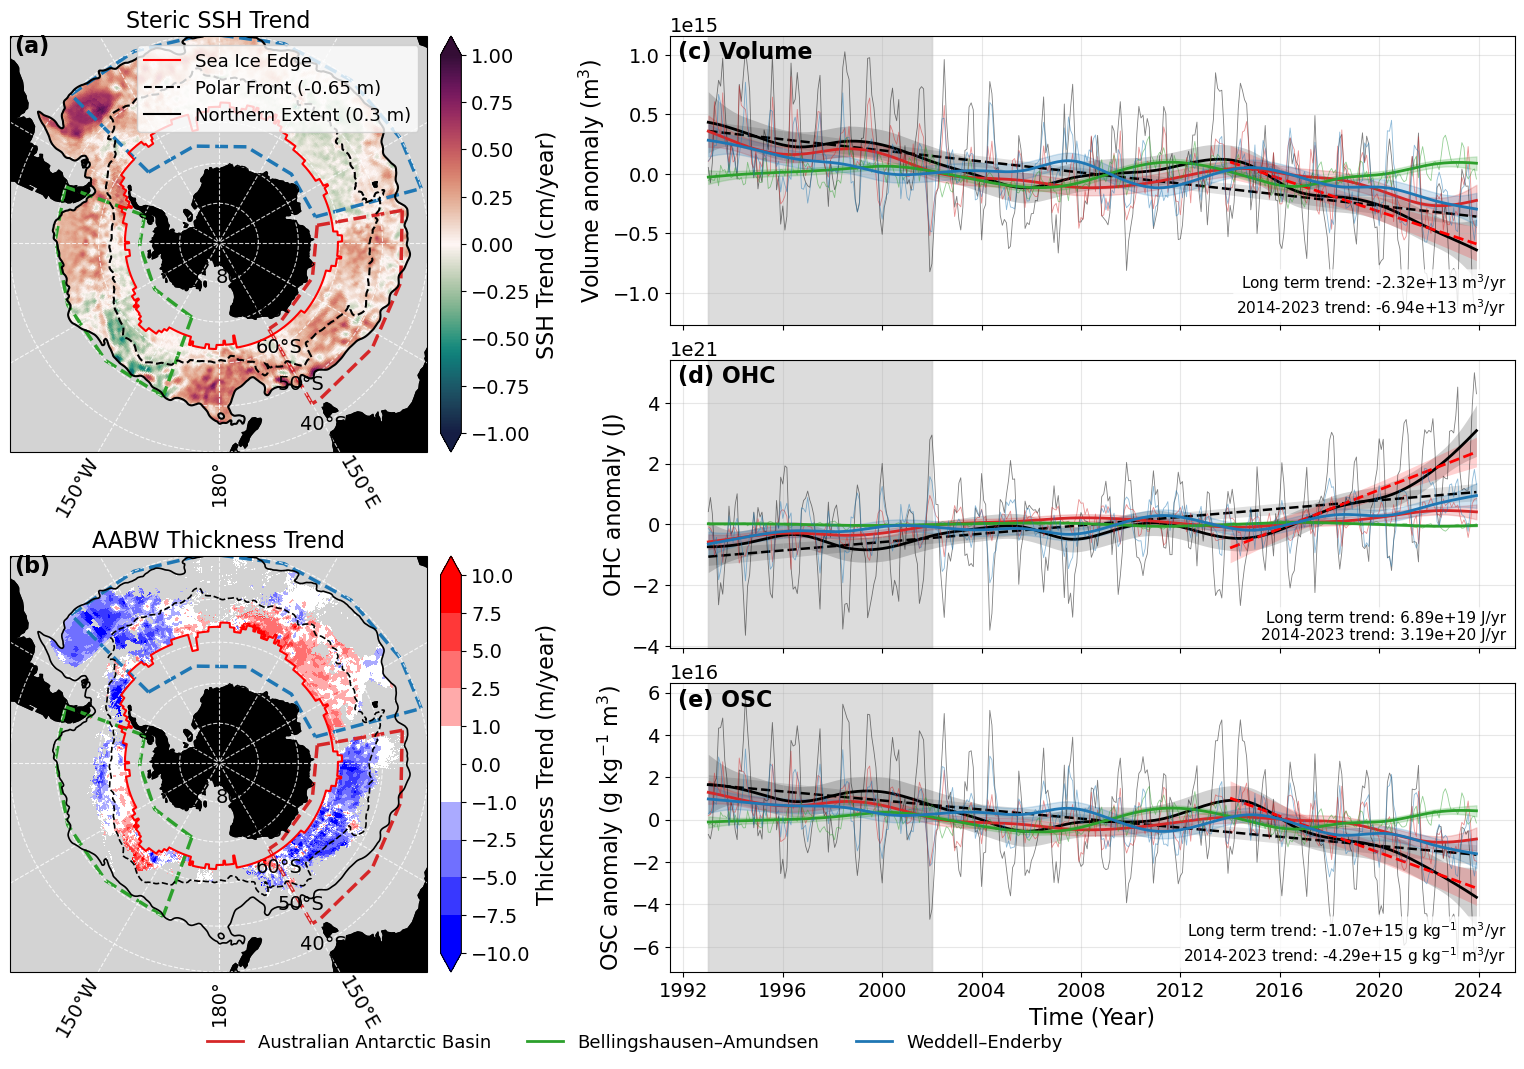

In [68]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import cmocean

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13
})

data_crs = ccrs.PlateCarree()

basin_keys   = ["AAB", "BA", "WE"]
basin_labels = row_labels
basin_colors = row_colors

basin_boxes = {
    "AAB": dict(lon=[80, 150],  lat_bot=-65, lat_top=-45),
    "BA" : dict(lon=[200, 290], lat_bot=-70, lat_top=-50),
    "WE" : dict(lon=[-45, 75],  lat_bot=-65, lat_top=-40),
}

# ---------------------------
# Basin anomalies
# ---------------------------
vol_triplet_anom = tuple(da - da.mean("time") for da in vol_triplet)
ohc_triplet_anom = tuple(da - da.mean("time") for da in ohc_triplet)
osc_triplet_anom = tuple(da - da.mean("time") for da in osc_triplet)

def add_grid(ax):
    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.8,
        color="white",
        alpha=0.8,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.xlabel_style = {"color": "black", "size": 14}
    gl.ylabel_style = {"color": "black", "size": 14}

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    gl.ylocator = mticker.FixedLocator(np.arange(-80, -39, 10))
    return gl

def smooth_lon_masked(da, window=3, weights=(1, 2, 1), periodic=True):
    w = np.asarray(weights, dtype=float)
    w = w / w.sum()

    if periodic:
        lon = da.longitude
        dlon = float(lon.diff('longitude').median())
        left  = da.isel(longitude=-1).assign_coords(longitude=lon.isel(longitude=0) - dlon)
        right = da.isel(longitude=0).assign_coords(longitude=lon.isel(longitude=-1) + dlon)
        da_pad = xr.concat([left, da, right], dim='longitude')

        win = da_pad.rolling(longitude=window, center=True, min_periods=1).construct("win")
        ww = xr.DataArray(w, dims=["win"])
        num = (win * ww).sum("win")
        den = xr.where(np.isfinite(win), 1.0, 0.0) * ww
        den = den.sum("win")
        out_pad = num / den

        out = out_pad.sel(longitude=lon)
        out = out.assign_coords(longitude=lon)
        return out

    win = da.rolling(longitude=window, center=True, min_periods=1).construct("win")
    ww = xr.DataArray(w, dims=["win"])
    num = (win * ww).sum("win")
    den = xr.where(np.isfinite(win), 1.0, 0.0) * ww
    den = den.sum("win")
    return num / den

# ---------------------------------
# Colormap with white gap for AABW thickness
# ---------------------------------
levels_year = np.arange(-10, 12.5, 2.5)
levels_year = np.unique(np.r_[levels_year, [-1, 1]])
levels_year.sort()

n_internal = len(levels_year) - 1
colors = plt.cm.bwr(np.linspace(0, 1, n_internal))
left, right = levels_year[:-1], levels_year[1:]
gap_bins = np.where((left >= -1) & (right <= 1))[0]
for gi in gap_bins:
    colors[gi] = (1, 1, 1, 1)

under = plt.cm.bwr(0.0)
over  = plt.cm.bwr(1.0)
colors_ext = np.vstack([under, colors, over])
cmap_gap = ListedColormap(colors_ext)
norm_gap = BoundaryNorm(levels_year, ncolors=cmap_gap.N, extend='both')

# ---------------------------------
# Figure layout: 1x2 outer, left: maps, right: time series
# ---------------------------------
fig = plt.figure(figsize=(22, 12))

outer_gs = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[1.1, 1.4],
    wspace=0.26
)

gs_left = outer_gs[0, 0].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[1, 1],
    hspace=0.25   # <<< MORE SPACE BETWEEN MAPS
)

gs_right = outer_gs[0, 1].subgridspec(
    nrows=3, ncols=1,
    hspace=0.12
)

# =========================================================
# LEFT TOP: (a) SSH TREND MAP
# =========================================================
ax_ssh = fig.add_subplot(gs_left[0, 0], projection=ccrs.SouthPolarStereo())
ax_ssh.set_facecolor("lightgray")
ax_ssh.add_feature(cfeature.LAND, facecolor="black", edgecolor="black", zorder=2)
ax_ssh.coastlines(color="black", linewidth=0.8, zorder=3)
ax_ssh.set_extent([-180, 180, -80, -40], crs=data_crs)

pcm_ssh = ax_ssh.pcolormesh(
    slope.longitude, slope.latitude,
    slope * 100.0,    # m/yr → cm/yr
    vmin=-1, vmax=1,
    shading='nearest',
    cmap=cmocean.cm.curl,
    transform=data_crs
)

ax_ssh.plot(longitude, sie_mask, 'r-', transform=data_crs, label='Sea Ice Edge', zorder=4)

ax_ssh.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude, ssh_circumpolar_mean,
    levels=[-0.65], colors='black', linestyles='--', linewidths=1.5,
    transform=data_crs, zorder=4
)
ax_ssh.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude, ssh_circumpolar_mean,
    levels=[0.3], colors='black', linestyles='-', linewidths=1.5,
    transform=data_crs, zorder=4
)

for label, color, key in zip(basin_labels, basin_colors, basin_keys):
    box = basin_boxes[key]
    lon1, lon2 = box["lon"]
    y1, y2 = box["lat_bot"], box["lat_top"]
    ax_ssh.plot([lon1, lon2], [y1, y1], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_ssh.plot([lon1, lon2], [y2, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_ssh.plot([lon1, lon1], [y1, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_ssh.plot([lon2, lon2], [y1, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)

add_grid(ax_ssh)

legend_handles = [
    mlines.Line2D([], [], color='r', linestyle='-',  label='Sea Ice Edge'),
    mlines.Line2D([], [], color='black', linestyle='--', label='Polar Front (-0.65 m)'),
    mlines.Line2D([], [], color='black', linestyle='-',  label='Northern Extent (0.3 m)'),
]
ax_ssh.legend(handles=legend_handles, loc='upper right')
ax_ssh.set_title("Steric SSH Trend", pad=6)
ax_ssh.text(0.01, 0.96, "(a)", transform=ax_ssh.transAxes, fontweight="bold")

# >>> vertical colourbar on the RIGHT of the map
cbar_ssh = fig.colorbar(
    pcm_ssh, ax=ax_ssh, orientation='vertical',
    pad=0.02, fraction=0.05, extend='both'
)
cbar_ssh.set_label("SSH Trend (cm/year)")

# =========================================================
# LEFT BOTTOM: (b) AABW THICKNESS TREND MAP
# =========================================================
ax_aabw = fig.add_subplot(gs_left[1, 0], projection=ccrs.SouthPolarStereo())
ax_aabw.set_facecolor("lightgray")
ax_aabw.add_feature(cfeature.LAND, facecolor="black", edgecolor="black", zorder=2)
ax_aabw.coastlines(color="black", linewidth=0.8, zorder=3)
ax_aabw.set_extent([-180, 180, -80, -40], crs=data_crs)

combined_mask = (area_mask | np.isnan(temp_g))

aabw_lon_smooth = smooth_lon_masked(
    AABW_thickness_trend.where(~combined_mask),
    window=3, weights=(1, 2, 1), periodic=True
).where(~combined_mask)

pcm_aabw = ax_aabw.pcolormesh(
    AABW_thickness_trend.longitude,
    AABW_thickness_trend.latitude,
    aabw_lon_smooth * 12.0,   # to m/year
    shading='nearest',
    cmap=cmap_gap, norm=norm_gap,
    transform=data_crs
)

ax_aabw.plot(longitude, sie_mask, 'r-', transform=data_crs, label='Sea Ice Boundary', zorder=4)
ax_aabw.contour(
    ssh_circumpolar_mean.longitude, ssh_circumpolar_mean.latitude,
    ssh_circumpolar_mean, levels=[-0.65, 0.3], colors='k', linewidths=1.2,
    transform=data_crs, zorder=4
)

for label, color, key in zip(basin_labels, basin_colors, basin_keys):
    box = basin_boxes[key]
    lon1, lon2 = box["lon"]
    y1, y2 = box["lat_bot"], box["lat_top"]
    ax_aabw.plot([lon1, lon2], [y1, y1], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_aabw.plot([lon1, lon2], [y2, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_aabw.plot([lon1, lon1], [y1, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)
    ax_aabw.plot([lon2, lon2], [y1, y2], linestyle='--', color=color, linewidth=2.5, transform=data_crs)

add_grid(ax_aabw)
ax_aabw.set_title("AABW Thickness Trend", pad=6)
ax_aabw.text(0.01, 0.96, "(b)", transform=ax_aabw.transAxes, fontweight="bold")

# >>> vertical colourbar on the RIGHT of the map
cbar_aabw = fig.colorbar(
    pcm_aabw, ax=ax_aabw, orientation='vertical',
    pad=0.02, fraction=0.05, ticks=levels_year, extend='both'
)
cbar_aabw.set_label("Thickness Trend (m/year)")

# =========================================================
# RIGHT COLUMN: TIME SERIES (TOTAL + BASIN ANOMALIES)
# =========================================================
ax_vol = fig.add_subplot(gs_right[0, 0])
ax_ohc = fig.add_subplot(gs_right[1, 0], sharex=ax_vol)
ax_osc = fig.add_subplot(gs_right[2, 0], sharex=ax_vol)

# -------------------------------
# (c) Volume anomalies (m³)
# -------------------------------
fit_gam_full_and_lastdecade(
    ax=ax_vol,
    time_da=aabw_normalised.time,
    data_da=aabw_normalised,
    label="Total AABW",
    wm_color="k",
    last_decade=(2014, 2024),
    ylabel=r"Volume anomaly (m$^{3}$)",
    trend_units=r"m$^{3}$"
)

# Basins: GAM+CI only, no trend labels in legends
for basin_label, basin_color, da in zip(basin_labels, basin_colors, vol_triplet_anom):
    fit_gam_with_ci(
        ax=ax_vol,
        time_da=da.time,
        data_da=da,
        label=f"_nolegend_{basin_label}",  # skip in any axis legends
        color=basin_color,
        ylabel=None
    )

ax_vol.text(0.01, 0.92, "(c) Volume", transform=ax_vol.transAxes, fontweight="bold")

# Remove any axis legend just in case
leg = ax_vol.get_legend()
if leg is not None:
    leg.remove()

# -------------------------------
# (d) OHC anomalies (J)
# -------------------------------
fit_gam_full_and_lastdecade(
    ax=ax_ohc,
    time_da=aabw_normalised_OHC.time,
    data_da=aabw_normalised_OHC,
    label="Total AABW",
    wm_color="k",
    last_decade=(2014, 2024),
    ylabel="OHC anomaly (J)",
    trend_units="J"
)

for basin_label, basin_color, da in zip(basin_labels, basin_colors, ohc_triplet_anom):
    fit_gam_with_ci(
        ax=ax_ohc,
        time_da=da.time,
        data_da=da,
        label=f"_nolegend_{basin_label}",
        color=basin_color,
        ylabel=None
    )

ax_ohc.text(0.01, 0.92, "(d) OHC", transform=ax_ohc.transAxes, fontweight="bold")

leg = ax_ohc.get_legend()
if leg is not None:
    leg.remove()

# -------------------------------
# (e) OSC anomalies (g kg^-1 m^3)
# -------------------------------
fit_gam_full_and_lastdecade(
    ax=ax_osc,
    time_da=aabw_normalised_OSC.time,
    data_da=aabw_normalised_OSC,
    label="Total AABW",
    wm_color="k",
    last_decade=(2014, 2024),
    ylabel=r"OSC anomaly (g kg$^{-1}$ m$^{3}$)",
    trend_units=r"g kg$^{-1}$ m$^{3}$"
)

for basin_label, basin_color, da in zip(basin_labels, basin_colors, osc_triplet_anom):
    fit_gam_with_ci(
        ax=ax_osc,
        time_da=da.time,
        data_da=da,
        label=f"_nolegend_{basin_label}",
        color=basin_color,
        ylabel=None
    )

ax_osc.text(0.01, 0.92, "(e) OSC", transform=ax_osc.transAxes, fontweight="bold")
ax_osc.set_xlabel("Time (Year)")

leg = ax_osc.get_legend()
if leg is not None:
    leg.remove()

# Hide x labels on top two
for ax in (ax_vol, ax_ohc):
    plt.setp(ax.get_xticklabels(), visible=False)

# Adjust bottom margin to make space for global legend
fig.subplots_adjust(bottom=0.10)

# Global legend for basins (only colours & labels)
basin_handles = [
    mlines.Line2D([], [], color=c, lw=2)
    for c in basin_colors
]

fig.legend(
    basin_handles,
    basin_labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02)
)

# plt.savefig('/g/data/jk72/jw2777/Paper_2_figs/AABW/updated_decline_fig.png', dpi=300, bbox_inches='tight')

plt.show()




## Figure 3

In [69]:
sie = xr.open_dataset('/g/data/jk72/jw2777/AABW_paper_clean/figure_data/ANTARCTIC_OMI_SI_extent.nc').siextents_mean

In [74]:
sie_september = sie.sel(time=sie['time'].dt.month == 9)
sie_september_anom = sie_september - sie_september.mean(dim='time')

def fit_gam_with_ci(ax, time_da, data_da, label, color):
    # Convert time to fractional years
    x = pd.to_datetime(time_da.values).astype(np.int64) / 1e9 / (60 * 60 * 24 * 365.25)
    y = data_da.values

    # Remove NaNs
    valid = ~np.isnan(y)
    x = x[valid]
    y = y[valid]

    # Fit GAM
    gam = GAM(s(0)).fit(x, y)

    # Predict over a smooth time grid
    x_pred = np.linspace(x.min(), x.max(), 500)
    y_pred = gam.predict(x_pred)
    y_ci = gam.confidence_intervals(x_pred, width=0.95)

    time_pred = pd.to_datetime(x_pred * 365.25, unit='D')

    # Plot raw data and GAM fit
    ax.plot(pd.to_datetime(time_da.values), data_da.values, linewidth=0.5, alpha=0.5, color=color)
    ax.plot(time_pred, y_pred, color=color, label=label)
    ax.fill_between(time_pred, y_ci[:, 0], y_ci[:, 1], color=color, alpha=0.2)
    # ax.set_title(label)
    ax.set_ylabel('Volume Anomaly (m³)')
    ax.grid(True)
    # Shade the extrapolated period (1993–2002)
    ax.axvspan(pd.to_datetime("1993-01-01"), pd.to_datetime("2002-01-01"), color='lightgray', alpha=0.3, zorder=0)
    # Return prediction and CI for further processing
    return {
        'label': label,
        'time_pred': time_pred,
        'y_pred': y_pred,
        'y_ci': y_ci
    }

def fit_gam_with_ci_no_plot(time_da, data_da):
    # Convert time to fractional years
    x = pd.to_datetime(time_da.values).astype(np.int64) / 1e9 / (60 * 60 * 24 * 365.25)
    y = data_da.values

    # Remove NaNs
    valid = ~np.isnan(y)
    x = x[valid]
    y = y[valid]

    # Fit GAM
    gam = GAM(s(0)).fit(x, y)

    # Predict over a smooth time grid
    x_pred = np.linspace(x.min(), x.max(), 500)
    y_pred = gam.predict(x_pred)
    y_ci = gam.confidence_intervals(x_pred, width=0.95)

    # Convert x_pred back to datetime
    time_pred = pd.to_datetime(x_pred * 365.25, unit='D')

    return {
        'time_pred': time_pred,
        'y_pred': y_pred,
        'y_ci': y_ci
    }

predictions = {}
predictions['AABW'] = fit_gam_with_ci_no_plot(aabw_normalised.time, aabw_normalised)


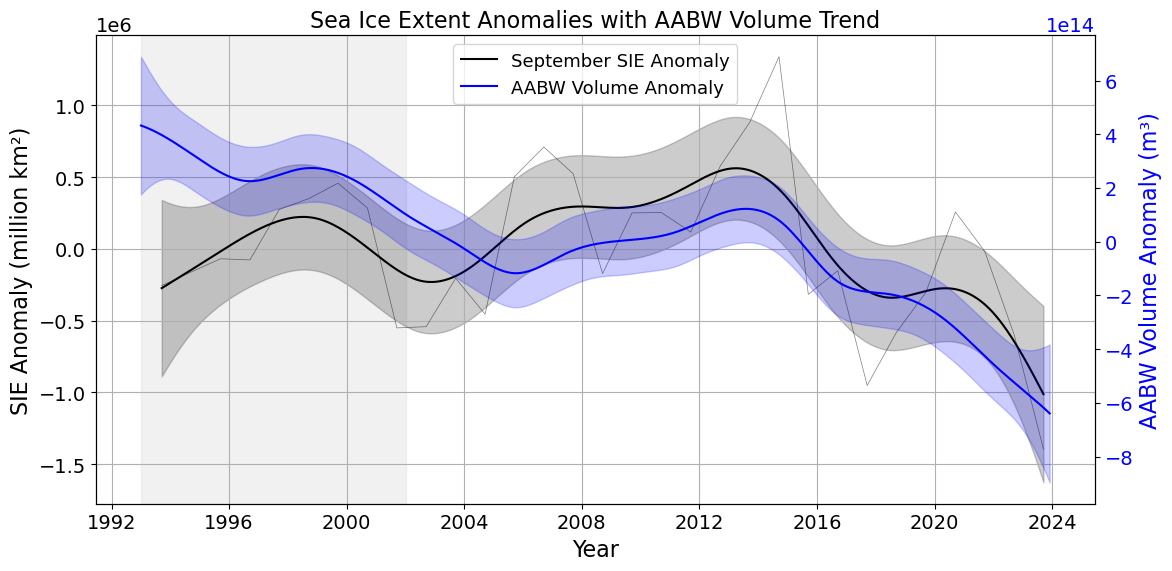

In [75]:
sie_september_fit = fit_gam_with_ci_no_plot(sie_september_anom.time, sie_september_anom)

# Start fresh figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot September and March anomalies with GAM fits and CI on left y-axis
fit_gam_with_ci(ax1, sie_september_anom.time, sie_september_anom, 'September SIE Anomaly', 'black')
# fit_gam_with_ci(ax1, sie_march_anom.time, sie_march_anom, 'March SIE Anomaly', 'orange')

# Label and axis settings
ax1.set_ylabel("SIE Anomaly (million km²)")
ax1.set_xlabel("Year")
ax1.legend(loc='upper left')
ax1.grid(True)

# Right-hand axis for AABW
ax2 = ax1.twinx()

# Extract AABW prediction from previous results
aabw = predictions['AABW']
ax2.plot(aabw['time_pred'], aabw['y_pred'], color='blue', label='AABW Volume Anomaly')
ax2.fill_between(aabw['time_pred'], aabw['y_ci'][:, 0], aabw['y_ci'][:, 1], color='blue', alpha=0.2)
ax2.set_ylabel('AABW Volume Anomaly (m³)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.title("Sea Ice Extent Anomalies with AABW Volume Trend")
plt.tight_layout()

# save_path = "/g/data/jk72/jw2777/Paper_2_figs/AABW/SIE_AABW.png"
# plt.savefig(save_path, dpi=300, bbox_inches='tight')


plt.show()


In [77]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.dates as mdates

# Time window
start = pd.to_datetime("2004-01-01")
end   = pd.to_datetime("2024-12-31")
aabw = predictions['AABW']
sie  = sie_september_fit
aabw_time = pd.to_datetime(aabw['time_pred'])
sie_time  = pd.to_datetime(sie['time_pred'])

aabw_num = mdates.date2num(aabw_time)
sie_num  = mdates.date2num(sie_time)
mask = (sie_time >= start) & (sie_time <= end)

sie_time_win = sie_time[mask]
sie_num_win  = sie_num[mask]
sie_pred_win = sie['y_pred'][mask]
aabw_interp_win = np.interp(
    x=sie_num_win,
    xp=aabw_num,
    fp=aabw['y_pred']
)
r_value, p_value = pearsonr(aabw_interp_win, sie_pred_win)

print("Correlation between AABW GAM and September SIE GAM (2004–2024):")
print(f"   r = {r_value:.3f}")
print(f"   p = {p_value:.3e}")


Correlation between AABW GAM and September SIE GAM (2004–2024):
   r = 0.953
   p = 1.030e-170
